# 05 - Near-Duplicates With MinHash and LSH

"Deduplicate the training set." "Find the near-identical support tickets." "Which of these listings
are the same listing posted twice?"

These get treated as hard, open-ended problems, and teams build slow pairwise pipelines for them.
They are not open-ended. They were solved in 1997, the method is a few dozen lines, and it is the
same hashing idea as everything else in this project - pointed at a new question: not *have I seen
this exact thing*, but *have I seen something almost like it*.

The obstacle is arithmetic. Comparing every document with every other is quadratic: 400 documents
is 79,800 comparisons, 100,000 documents is 5 billion, and a million documents is half a trillion.
Any method that looks at all pairs is finished before it starts.

Two ideas fix it:

1. **MinHash** compresses a document to a short signature such that the *rate at which two
   signatures agree is the similarity of the documents*;
2. **LSH** hashes those signatures so that similar ones collide, turning the search for similar
   pairs into a dictionary lookup.

In [1]:
%matplotlib inline

import time

import pandas as pd

from src.config import get_settings
from src.data import generate_text_corpus
from src.evaluation.comparison import compare_near_duplicate_search
from src.evaluation.error_analysis import lsh_recall_report, minhash_error_curve
from src.results import results_dir, save_results
from src.similarity.lsh import MinHashLSH, approximate_threshold, candidate_probability, choose_parameters
from src.similarity.minhash import MinHasher, jaccard, shingles
from src.visualisation import plot_lsh_s_curve, plot_minhash_accuracy, save_figure

SETTINGS = get_settings()
SEED = SETTINGS.seed
NUM_PERM = SETTINGS.minhash.num_perm
SHINGLE_SIZE = SETTINGS.minhash.shingle_size

corpus = generate_text_corpus(
    n_docs=SETTINGS.corpus.n_docs,
    n_near_duplicates=SETTINGS.corpus.n_near_duplicates,
    doc_words=SETTINGS.corpus.doc_words,
    vocabulary_size=SETTINGS.corpus.vocabulary_size,
    edit_fraction=SETTINGS.corpus.edit_fraction,
    seed=SEED,
)

print(f"corpus: {corpus.n_documents} documents, {len(corpus.duplicate_pairs)} planted "
      f"near-duplicate pairs, {corpus.n_all_pairs:,} possible pairs")

corpus: 400 documents, 40 planted near-duplicate pairs, 79,800 possible pairs


## First, turn a document into a set

Similarity between documents becomes similarity between *sets* by cutting each document into
overlapping windows - **shingles**. With 5-word shingles, two documents that share long passages
share many shingles, and word order is preserved inside each window (unlike a bag of words).

The measure is Jaccard similarity: the size of the intersection over the size of the union. 1.0 is
identical, 0.0 is nothing in common.

In [2]:
original = corpus.documents[0]
planted_pair = sorted(corpus.duplicate_pairs)[0]
near_copy = corpus.documents[planted_pair[1]]
unrelated = corpus.documents[7]

sets = {
    "original": shingles(original, SHINGLE_SIZE),
    "near copy": shingles(near_copy, SHINGLE_SIZE),
    "unrelated": shingles(unrelated, SHINGLE_SIZE),
}

print(f"original  : {corpus.documents[planted_pair[0]][:88]}...")
print(f"near copy : {near_copy[:88]}...")
print()
print(f"shingles per document        : {len(sets['original'])}")
print(f"J(original, near copy)       : "
      f"{jaccard(shingles(corpus.documents[planted_pair[0]], SHINGLE_SIZE), sets['near copy']):.3f}")
print(f"J(original, unrelated)       : "
      f"{jaccard(shingles(corpus.documents[planted_pair[0]], SHINGLE_SIZE), sets['unrelated']):.3f}")

original  : encoder0 signal4 signal10 model2 shard0 bit4 shard6 bucket10 cache9 memory5 rate3 batch2...
near copy : encoder0 signal4 signal10 model2 shard0 bit4 shard6 bucket10 cache9 memory5 rate3 batch2...

shingles per document        : 56
J(original, near copy)       : 0.697
J(original, unrelated)       : 0.000


## MinHash: the whole idea in one sentence

Hash every element of a set and keep only the **smallest** hash.

Because the hash is random-looking, every element of the union is equally likely to be the one that
produced the minimum. So the chance that two sets have the *same* minimum is exactly the chance
that this element is in their intersection:

```
P(min_h(A) == min_h(B)) = |A n B| / |A u B| = J(A, B)
```

One hash gives one coin flip of evidence. Repeat with `k` independent hashes and count how often
the two signatures agree: that fraction estimates J, with standard error `sqrt(J(1-J)/k)`. With
`k = 128` that is about 4 percentage points - from 128 numbers per document, no matter how long the
document is.

In [3]:
hasher = MinHasher(num_perm=NUM_PERM, seed=SEED)

signature_original = hasher.signature(shingles(corpus.documents[planted_pair[0]], SHINGLE_SIZE))
signature_copy = hasher.signature(sets["near copy"])
signature_unrelated = hasher.signature(sets["unrelated"])

true_similar = jaccard(shingles(corpus.documents[planted_pair[0]], SHINGLE_SIZE), sets["near copy"])
true_unrelated = jaccard(shingles(corpus.documents[planted_pair[0]], SHINGLE_SIZE), sets["unrelated"])

print(f"signature length: {len(signature_original)} numbers "
      f"({hasher.memory_bytes()} bytes per document, whatever its size)")
print()
print(f"estimated J(original, near copy) : {hasher.estimated_jaccard(signature_original, signature_copy):.3f}"
      f"   true {true_similar:.3f}")
print(f"estimated J(original, unrelated) : {hasher.estimated_jaccard(signature_original, signature_unrelated):.3f}"
      f"   true {true_unrelated:.3f}")

signature length: 128 numbers (1024 bytes per document, whatever its size)

estimated J(original, near copy) : 0.711   true 0.697
estimated J(original, unrelated) : 0.000   true 0.000


### How good is the estimate?

Across a range of true similarities, with sets built to have an exact known Jaccard. The error bars
are three standard errors of the estimator itself - and they shrink as `1/sqrt(k)`, so 512
permutations halve the error of 128.

In [4]:
accuracy = minhash_error_curve(
    similarities=SETTINGS.minhash.similarities,
    num_perm=NUM_PERM,
    set_size=500,
    seed=SEED,
)
accuracy.round(4)

,true_jaccard,estimated_jaccard,abs_error,expected_std,within_3_sigma,signature_bytes
0,0.2005,0.1797,0.0208,0.0354,True,1024
1,0.4006,0.4219,0.0213,0.0433,True,1024
2,0.6000,0.5938,0.0062,0.0433,True,1024
3,0.7986,0.7578,0.0407,0.0355,True,1024
4,0.9493,0.9531,0.0038,0.0194,True,1024


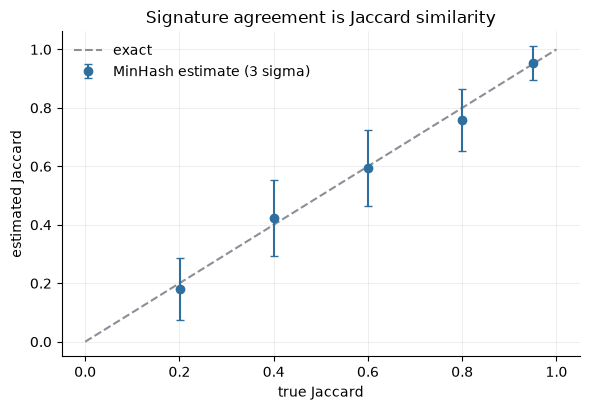

In [5]:
figure = plot_minhash_accuracy(accuracy)
save_figure(figure, "05_minhash_accuracy")
figure

In [6]:
saved = save_results(
    {
        "num_perm": NUM_PERM,
        "signature_bytes": hasher.memory_bytes(),
        "shingle_size": SHINGLE_SIZE,
        "accuracy": accuracy,
        "example_pair": {
            "document_a": corpus.documents[planted_pair[0]],
            "document_b": near_copy,
            "true_jaccard": true_similar,
            "estimated_jaccard": hasher.estimated_jaccard(signature_original, signature_copy),
        },
        "all_within_3_sigma": bool(accuracy["within_3_sigma"].all()),
    },
    "05_minhash_accuracy",
)
print("saved ->", saved.name)

saved -> 05_minhash_accuracy.json


## LSH: never compare the pairs you do not have to

Signatures shrink each document, but comparing all pairs of signatures is still quadratic. The last
step removes the quadratic term entirely.

Cut each signature into `b` bands of `r` rows, and hash each band into a bucket. Two documents
become **candidates** if they collide in *any* band. Since a whole band matches with probability
`s^r` when the true similarity is `s`:

```
P(candidate | similarity s) = 1 - (1 - s^r)^b
```

That is an S-curve with a knee near `(1/b)^(1/r)`. Below the knee almost nothing is a candidate;
above it almost everything is. You are choosing a similarity threshold by choosing a banding - and
then near-duplicate search is a dictionary lookup.

In [7]:
bandings = [(8, 16), (16, 8), (32, 4), (64, 2)]

s_curve_table = pd.DataFrame(
    [
        {
            "num_bands": bands,
            "rows_per_band": rows,
            "threshold": approximate_threshold(bands, rows),
            "P(candidate | s=0.4)": candidate_probability(0.4, bands, rows),
            "P(candidate | s=0.7)": candidate_probability(0.7, bands, rows),
            "P(candidate | s=0.9)": candidate_probability(0.9, bands, rows),
        }
        for bands, rows in bandings
    ]
)

chosen_bands, chosen_rows = choose_parameters(NUM_PERM, SETTINGS.lsh.target_threshold)
print(f"for a target threshold of {SETTINGS.lsh.target_threshold}, "
      f"{NUM_PERM} permutations split best as b={chosen_bands}, r={chosen_rows} "
      f"(knee at {approximate_threshold(chosen_bands, chosen_rows):.2f})")
s_curve_table.round(4)

for a target threshold of 0.5, 128 permutations split best as b=32, r=4 (knee at 0.42)


,num_bands,rows_per_band,threshold,P(candidate | s=0.4),P(candidate | s=0.7),P(candidate | s=0.9)
0,8,16,0.8781,0.0000,0.0263,0.8059
1,16,8,0.7071,0.0104,0.6133,0.9999
2,32,4,0.4204,0.5639,0.9998,1.0000
3,64,2,0.1250,1.0000,1.0000,1.0000


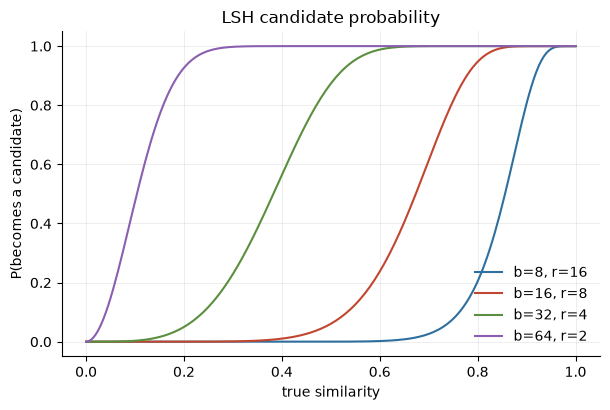

In [8]:
figure = plot_lsh_s_curve(bandings)
save_figure(figure, "05_lsh_s_curve")
figure

## Running it on the corpus

Index every document, then ask which pairs share a bucket. Ground truth here is the exhaustive
all-pairs Jaccard, so recall is measured rather than assumed.

The `work_ratio` column is the point of the notebook: the fraction of all possible pairs LSH
actually looked at.

In [9]:
recall_report = lsh_recall_report(
    corpus,
    bandings=[(16, 8), (32, 4), (64, 2)],
    shingle_size=SHINGLE_SIZE,
    similarity_threshold=0.5,
    seed=SEED,
)
recall_report.round(4)

,num_bands,rows_per_band,num_perm,threshold,true_pairs,candidate_pairs,all_pairs,work_ratio,recall,precision
0,16,8,128,0.7071,40,24,79800,0.0003,0.6,1.0
1,32,4,128,0.4204,40,40,79800,0.0005,1.0,1.0
2,64,2,128,0.1250,40,40,79800,0.0005,1.0,1.0


In [10]:
saved = save_results(
    {
        "s_curve": s_curve_table,
        "chosen_banding": {"num_bands": chosen_bands, "rows_per_band": chosen_rows},
        "recall_report": recall_report,
        "note": (
            "Measured recall tracks the S-curve prediction: a banding whose knee sits below the "
            "similarity of the planted pairs finds essentially all of them."
        ),
    },
    "05_lsh_recall",
)
print("saved ->", saved.name)

saved -> 05_lsh_recall.json


## The comparison that matters

Exhaustive search against MinHash + LSH, same corpus, same threshold, both timed. The
`comparisons` column is what grows quadratically for one method and barely at all for the other.

In [11]:
search_comparison = compare_near_duplicate_search(
    corpus,
    num_bands=SETTINGS.lsh.num_bands,
    rows_per_band=SETTINGS.lsh.rows_per_band,
    shingle_size=SHINGLE_SIZE,
    similarity_threshold=0.5,
    seed=SEED,
)
search_comparison.round(4)

,method,comparisons,pairs_found,recall,seconds
0,all pairs,79800,40,1.0,0.5779
1,"minhash + lsh (b=32, r=4)",40,40,1.0,0.0584


At 400 documents the wall-clock win is modest - both finish in under a second. That is exactly the
scale at which people conclude the naive approach is fine, and it is why the *comparisons* column
matters more than the seconds. Comparisons grow as n^2 for one row and roughly as n for the other.
Extrapolate the same ratio to 100,000 documents and the exhaustive method needs 5 billion Jaccard
computations while LSH still looks at a few thousand candidate pairs.

In [12]:
projection_rows = []
observed_work_ratio = float(
    search_comparison.loc[1, "comparisons"] / search_comparison.loc[0, "comparisons"]
)
for n_docs in (400, 10_000, 100_000, 1_000_000):
    all_pairs = n_docs * (n_docs - 1) // 2
    projection_rows.append(
        {
            "n_documents": n_docs,
            "all_pairs": all_pairs,
            "lsh_candidate_pairs_projected": all_pairs * observed_work_ratio,
            "measured": n_docs == corpus.n_documents,
        }
    )
duplicate_search_projection = pd.DataFrame(projection_rows)

saved = save_results(
    {
        "comparison": search_comparison,
        "observed_work_ratio": observed_work_ratio,
        "projection": duplicate_search_projection,
        "projection_note": (
            "Rows beyond the corpus size scale the measured work ratio; they are projections, "
            "not runs, and the measured column says so."
        ),
    },
    "05_exact_vs_approximate",
)
print("saved ->", saved.name)
duplicate_search_projection.round(1)

saved -> 05_exact_vs_approximate.json


,n_documents,all_pairs,lsh_candidate_pairs_projected,measured
0,400,79800,40.0,True
1,10000,49995000,25060.2,False
2,100000,4999950000,2506240.6,False
3,1000000,499999500000,250626315.8,False


## What LSH actually found

Every pair below shares at least one band bucket. The near-identical ones are the planted
duplicates; if a pair with low similarity appears, that is a false candidate - cheap, because
candidates get verified exactly, and verification only runs on the shortlist.

In [13]:
shingle_sets = [shingles(document, SHINGLE_SIZE) for document in corpus.documents]
index = MinHashLSH(
    num_bands=SETTINGS.lsh.num_bands, rows_per_band=SETTINGS.lsh.rows_per_band, seed=SEED
)
start = time.perf_counter()
index.insert_many(list(range(corpus.n_documents)), hasher.signature_matrix(shingle_sets))
index_seconds = time.perf_counter() - start

planted = {(min(a, b), max(a, b)) for a, b in corpus.duplicate_pairs}
found = []
for a, b in sorted(index.candidate_pairs()):
    pair = (min(int(a), int(b)), max(int(a), int(b)))
    found.append(
        {
            "doc_a": pair[0],
            "doc_b": pair[1],
            "true_jaccard": jaccard(shingle_sets[pair[0]], shingle_sets[pair[1]]),
            "planted_duplicate": pair in planted,
        }
    )
candidates = pd.DataFrame(found).sort_values("true_jaccard", ascending=False)

print(f"indexed {corpus.n_documents} documents in {index_seconds:.2f}s")
print(f"candidate pairs: {len(candidates)} out of {corpus.n_all_pairs:,} possible")
print(f"planted pairs recovered: {int(candidates['planted_duplicate'].sum())} of {len(planted)}")
candidates.head(8).round(3)

indexed 400 documents in 0.08s
candidate pairs: 40 out of 79,800 possible
planted pairs recovered: 40 of 40


,doc_a,doc_b,true_jaccard,planted_duplicate
24,269,398,0.898,True
20,254,365,0.806,True
17,241,360,0.806,True
0,10,392,0.778,True
29,290,383,0.778,True
5,147,366,0.778,True
3,102,364,0.750,True
1,15,371,0.750,True


In [14]:
example = candidates.iloc[0]
print("closest pair the index surfaced:\n")
print(f"doc {int(example['doc_a'])}: {corpus.documents[int(example['doc_a'])][:120]}...")
print()
print(f"doc {int(example['doc_b'])}: {corpus.documents[int(example['doc_b'])][:120]}...")
print(f"\ntrue Jaccard {example['true_jaccard']:.3f}, planted duplicate: {bool(example['planted_duplicate'])}")

saved = save_results(
    {
        "index_seconds": index_seconds,
        "n_documents": corpus.n_documents,
        "candidate_pairs": len(candidates),
        "all_pairs": corpus.n_all_pairs,
        "planted_pairs": len(planted),
        "planted_recovered": int(candidates["planted_duplicate"].sum()),
        "index_memory_bytes": index.memory_bytes(),
        "candidates": candidates,
        "closest_pair_text": {
            "doc_a": corpus.documents[int(example["doc_a"])],
            "doc_b": corpus.documents[int(example["doc_b"])],
            "true_jaccard": float(example["true_jaccard"]),
        },
    },
    "05_found_duplicates",
)
print("saved ->", saved.name)

closest pair the index surfaced:

doc 269: cardinality5 bound0 vector8 bound3 cardinality3 count9 encoder6 shard0 duplicate2 shard8 noise6 bloom9 shard9 sketch1 un...

doc 398: cardinality5 bound0 vector8 bound3 cardinality3 count9 encoder6 shard0 duplicate2 shard8 noise6 bloom9 shard9 sketch1 un...

true Jaccard 0.898, planted duplicate: True
saved -> 05_found_duplicates.json


## What to take away

- Shingling turns documents into sets, and set similarity (Jaccard) is a workable definition of
  "almost the same".
- MinHash makes the *probability that two signatures agree equal to the Jaccard similarity*, so a
  fixed-size signature - 128 numbers, 1 KB - estimates similarity for a document of any length.
- LSH bands those signatures so similar ones collide, converting an all-pairs search into a
  dictionary lookup. The knee of the S-curve, `(1/b)^(1/r)`, is your similarity threshold, and you
  set it by choosing the banding.
- Recall is not free: pairs near the threshold get missed at a rate the S-curve predicts exactly.
  Choose the banding for the similarity you care about, then verify candidates exactly - the
  shortlist is small enough that you can.
- This is the deduplication tool. Training sets, crawled pages, support tickets, listings: build
  signatures, index, query.

Next: the same trick, applied to the columns of a model instead of the rows of a corpus.

In [15]:
takeaways = [
    "Shingling turns a document into a set; Jaccard similarity measures 'almost the same'.",
    "MinHash: P(signatures agree) = Jaccard, so a fixed 128-number signature estimates similarity.",
    "LSH bands signatures so similar ones collide - all-pairs search becomes a dictionary lookup.",
    "The S-curve knee (1/b)^(1/r) is the threshold; recall near it is predictable, not mysterious.",
    "Verify the shortlist exactly: LSH removes the quadratic term, not the need for a final check.",
]

saved = save_results({"takeaways": takeaways}, "05_takeaways")
print("saved ->", saved.name)
print("figures:", sorted(path.name for path in SETTINGS.figures.path.glob("05_*.png")))
print("results:", sorted(path.name for path in results_dir().glob("05_*.json")))

saved -> 05_takeaways.json
figures: ['05_lsh_s_curve.png', '05_minhash_accuracy.png']
results: ['05_exact_vs_approximate.json', '05_found_duplicates.json', '05_lsh_recall.json', '05_minhash_accuracy.json', '05_takeaways.json']
